<a href="https://colab.research.google.com/github/abrilalmeida/proyeto_britpop/blob/main/DataWranglingAlmeida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Proyecto de Abril Almeida
##Machine learning para Ciencia de datos

###La batalla del britpop

En este proyecto de data science utilizamos la API de Spotify para recolectar datos sobre los albumes poplulares de las bandas Blur y Oasis obteniendo las métricas de popularidad de las canciones de los albumes lanzados en 1994 (antes de la batalla) y 1995 (el 14 de agosto, cuando ambas bandas lanzaron sus sencillos para competir). Ademas, se analizaron datos de un dataset del top 100 de UK centrado en los años 1994 y 1995.

Se han elegido estas herramientas para el proyecto por su amplia variedad de opciones de exploración que nos ayudan a adentrarnos en el progreso de estas dos bandas britanicas. La web API de Spotify nos permite obtener información relevante sobre los albumes y canciones más populares como fecha de lanzamiento y la popularidad del 0 (nada popular) al 100 (muy popular) y el dataset del top 100 nos da una vista al pasado para poder comparar las trayectorias de canciones.

La batalla del britpop - en los años 90 en Gran Bretaña, dos bandas representaban al mismo genero, pero por motivos diferentes. Una provenia del sur de Inglaterra y la otra del norte, una construida por gente de clase media y otra por gente de clase obrera. Blur y Oasis.

En este proyecto vamos a analizar los altos y los bajos de ambas bandas con el fin de determinar quien fue realmente el ganador pero investigando más alla de las opiñones individuales de la gente, centrandonos en la progresión de popularidad a lo largo del tiempo y puntualmente en el pico de interes por la batalla que fue 1995.

***Preguntas e Hipótesis***

1. ¿Quién tuvo mayor éxito después de la batalla?
2. Blur gano la batalla inicial en las listas del momento pero Oasis fue el ganador a largo plazo.
3. Si Blur siguiera tocando tendria mas exito que Oasis.

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from openpyxl import load_workbook
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
from google.colab import userdata

Client_ID = userdata.get('ClientID')
Client_Secret = userdata.get('ClientSecret')

###Dataset del top 100 de Inglaterra: datos de 1994 - 1995

In [3]:
url = "https://github.com/abrilalmeida/proyeto_britpop/raw/refs/heads/main/excel_reducido.xlsx"
df_top_completo = pd.read_excel(url, sheet_name=None)

In [4]:
df_top_100 = pd.concat(df_top_completo.values(), ignore_index=True)

###Web Api de Spotify

In [5]:
auth_url = "https://accounts.spotify.com/api/token"
headers = {
    "Content-Type": "application/x-www-form-urlencoded"
    }
data = {"grant_type": "client_credentials",
             "client_id": Client_ID,
             "client_secret": Client_Secret}

response = requests.post(auth_url, headers=headers, data=data)

In [6]:
response.json()

{'access_token': 'BQDqjvHpxJ7TE08pyX_YHRe1cyNmU9xfZ2-app7gYDxSCFq37PjzLDg4Q1HzC5xZtOsaUXBCfDPa0MhCYv7W504SotAr-WBU5OeI7Y4aG94164tPKOvwOUu91GoXin6poj1HkmtsZgA',
 'token_type': 'Bearer',
 'expires_in': 3600}

In [7]:
access_token = response.json()['access_token']
print(access_token)

BQDqjvHpxJ7TE08pyX_YHRe1cyNmU9xfZ2-app7gYDxSCFq37PjzLDg4Q1HzC5xZtOsaUXBCfDPa0MhCYv7W504SotAr-WBU5OeI7Y4aG94164tPKOvwOUu91GoXin6poj1HkmtsZgA


#Obtener albumes

##Blur: Parklife (1994) y The great escape (1995)

In [8]:
tge_url = "https://open.spotify.com/album/3rXnMAuqzR6UQl6gBlJrDL?si=HLUHp513SfyQGvhg4iU2zA"
tge_id = tge_url.split("/")[-1].split("?")[0]

print(f"The great escape id: {tge_id}]")

parklife_url = "https://open.spotify.com/album/0DBkFC6739trhCoVreZyds?si=_HZCAvGYRYSMHEHyRl16Lg"
parklife_id = parklife_url.split("/")[-1].split("?")[0]

print(f"Parklife id: {parklife_id}")

The great escape id: 3rXnMAuqzR6UQl6gBlJrDL]
Parklife id: 0DBkFC6739trhCoVreZyds


In [9]:
album_tge_url = f"https://api.spotify.com/v1/albums/{tge_id}"
album_parklife_url = f"https://api.spotify.com/v1/albums/{parklife_id}"

headers = {"Authorization": f"Bearer {access_token}"}

res_tge = requests.get(url=album_tge_url, headers=headers)
res_parklife = requests.get(url=album_parklife_url, headers=headers)

print(res_tge.json())
print(res_parklife.json())

{'album_type': 'album', 'total_tracks': 15, 'available_markets': ['AR', 'AU', 'AT', 'BE', 'BO', 'BR', 'BG', 'CA', 'CL', 'CO', 'CR', 'CY', 'CZ', 'DK', 'DO', 'DE', 'EC', 'EE', 'SV', 'FI', 'FR', 'GR', 'GT', 'HN', 'HK', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'MY', 'MT', 'MX', 'NL', 'NZ', 'NI', 'NO', 'PA', 'PY', 'PE', 'PH', 'PL', 'PT', 'SG', 'SK', 'ES', 'SE', 'CH', 'TW', 'TR', 'UY', 'US', 'GB', 'AD', 'LI', 'MC', 'ID', 'JP', 'TH', 'VN', 'RO', 'IL', 'ZA', 'SA', 'AE', 'BH', 'QA', 'OM', 'KW', 'EG', 'MA', 'DZ', 'TN', 'LB', 'JO', 'PS', 'IN', 'BY', 'KZ', 'MD', 'UA', 'AL', 'BA', 'HR', 'ME', 'MK', 'RS', 'SI', 'KR', 'BD', 'PK', 'LK', 'GH', 'KE', 'NG', 'TZ', 'UG', 'AG', 'AM', 'BS', 'BB', 'BZ', 'BT', 'BW', 'BF', 'CV', 'CW', 'DM', 'FJ', 'GM', 'GE', 'GD', 'GW', 'GY', 'HT', 'JM', 'KI', 'LS', 'LR', 'MW', 'MV', 'ML', 'MH', 'FM', 'NA', 'NR', 'NE', 'PW', 'PG', 'PR', 'WS', 'SM', 'ST', 'SN', 'SC', 'SL', 'SB', 'KN', 'LC', 'VC', 'SR', 'TL', 'TO', 'TT', 'TV', 'VU', 'AZ', 'BN', 'BI', 'KH', 'CM', 'TD', 'KM', 'GQ'

In [10]:
tge_track_ids = []
parklife_track_ids = []

for item in res_tge.json()["tracks"]["items"]:
    track = item
    tge_track_ids.append(track["id"])

for item in res_parklife.json()["tracks"]["items"]:
    track = item
    parklife_track_ids.append(track["id"])


print(tge_track_ids)
print(parklife_track_ids)

['0GmbxnQnsCND5CqnHVNbd7', '7hpqbNRHs7S2kE9HGko6PS', '4ScB2fXeObS3m5N8uEDjog', '08l0WDhkcMNh0fGxK6d8ig', '3hbb9IEUrSrtr0nXTJDkfU', '5vpy4y1gNneK9jAsqirJBg', '1AiidNX48Lq5K4snCm8www', '4oDAiTKmrdmd84Tq51R1vd', '5oouHAnTSnTqGl2IoLAZDc', '5ACPXwE34GmPhHAuUHEycE', '7aKYHZZuQtgRPhKPMecSO1', '2tB1Aflgr5aRh65g1oRbRH', '31R0GNbwZcgkL1BMXXNcMZ', '6u42HJZp8g9UHgWaeU7yfw', '0SntAp07ONKCC3xzO7lERz']
['2qrL1YF9aA865b6SKhLZ78', '6xjks1MbmXNPRewKoeyklJ', '22CkOnnHglpw77NeYOc0I5', '7FSzJQV6thyoQptFCUTV9c', '0mQaNN28Z99hB1P53xriR1', '3uPfYnQECyloQNT36LTVSB', '1zXo3qaQrAoeRElnFVsUST', '734oBDdb6t65JvLAhIqX72', '7u8yddev0YnNFGkZoP8X2t', '07jg7DcGoyFfL0DoZia4VK', '49FLhuOp7wY4T1apsKoyET', '6ErEhafrAEQArcTZgnRpTJ', '4EcSkkNLSHSWy5AFktHu6N', '5R7Vhx8xJyzi5r5tLLrlPS', '1Ce0LuCifEoGTnf9MbXQbo', '4MCYT8YoWcW31qYKZ6lAbJ', '5aL3bfDsE0aOum2YJ1APL0', '4HEZub1WxyrIACVByMlsmU', '0v3Iu3EJlX0eT89PCwEVaE', '5w6SlihcH5jAm8H5s36LPE', '3L5122kKzoI6UV4T3ei3N4', '4MuWmmDeS4B1hGnErbBCKD', '1A9BfYFe9yuRoHDZjogHmp', '2LImWLD6G

In [11]:
url = "https://api.spotify.com/v1/tracks"
params = {"ids": ",".join(tge_track_ids)}

tge_tracks_res = requests.get(url, headers=headers, params=params)
print(tge_tracks_res.json())

{'tracks': [{'album': {'album_type': 'album', 'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/7MhMgCo0Bl0Kukl93PZbYS'}, 'href': 'https://api.spotify.com/v1/artists/7MhMgCo0Bl0Kukl93PZbYS', 'id': '7MhMgCo0Bl0Kukl93PZbYS', 'name': 'Blur', 'type': 'artist', 'uri': 'spotify:artist:7MhMgCo0Bl0Kukl93PZbYS'}], 'available_markets': ['AR', 'AU', 'AT', 'BE', 'BO', 'BR', 'BG', 'CA', 'CL', 'CO', 'CR', 'CY', 'CZ', 'DK', 'DO', 'DE', 'EC', 'EE', 'SV', 'FI', 'FR', 'GR', 'GT', 'HN', 'HK', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'MY', 'MT', 'MX', 'NL', 'NZ', 'NI', 'NO', 'PA', 'PY', 'PE', 'PH', 'PL', 'PT', 'SG', 'SK', 'ES', 'SE', 'CH', 'TW', 'TR', 'UY', 'US', 'GB', 'AD', 'LI', 'MC', 'ID', 'JP', 'TH', 'VN', 'RO', 'IL', 'ZA', 'SA', 'AE', 'BH', 'QA', 'OM', 'KW', 'EG', 'MA', 'DZ', 'TN', 'LB', 'JO', 'PS', 'IN', 'BY', 'KZ', 'MD', 'UA', 'AL', 'BA', 'HR', 'ME', 'MK', 'RS', 'SI', 'KR', 'BD', 'PK', 'LK', 'GH', 'KE', 'NG', 'TZ', 'UG', 'AG', 'AM', 'BS', 'BB', 'BZ', 'BT', 'BW', 'BF', 'CV'

In [12]:
url = "https://api.spotify.com/v1/tracks"
params = {"ids": ",".join(parklife_track_ids)}

parklife_tracks_res = requests.get(url, headers=headers, params=params)
print(parklife_tracks_res.json())

{'tracks': [{'album': {'album_type': 'album', 'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/7MhMgCo0Bl0Kukl93PZbYS'}, 'href': 'https://api.spotify.com/v1/artists/7MhMgCo0Bl0Kukl93PZbYS', 'id': '7MhMgCo0Bl0Kukl93PZbYS', 'name': 'Blur', 'type': 'artist', 'uri': 'spotify:artist:7MhMgCo0Bl0Kukl93PZbYS'}], 'available_markets': ['AR', 'AU', 'AT', 'BE', 'BO', 'BR', 'BG', 'CA', 'CL', 'CO', 'CR', 'CY', 'CZ', 'DK', 'DO', 'DE', 'EC', 'EE', 'SV', 'FI', 'FR', 'GR', 'GT', 'HN', 'HK', 'HU', 'IS', 'IE', 'IT', 'LV', 'LT', 'LU', 'MY', 'MT', 'MX', 'NL', 'NZ', 'NI', 'NO', 'PA', 'PY', 'PE', 'PH', 'PL', 'PT', 'SG', 'SK', 'ES', 'SE', 'CH', 'TW', 'TR', 'UY', 'US', 'GB', 'AD', 'LI', 'MC', 'ID', 'JP', 'TH', 'VN', 'RO', 'IL', 'ZA', 'SA', 'AE', 'BH', 'QA', 'OM', 'KW', 'EG', 'MA', 'DZ', 'TN', 'LB', 'JO', 'PS', 'IN', 'BY', 'KZ', 'MD', 'UA', 'AL', 'BA', 'HR', 'ME', 'MK', 'RS', 'SI', 'KR', 'BD', 'PK', 'LK', 'GH', 'KE', 'NG', 'TZ', 'UG', 'AG', 'AM', 'BS', 'BB', 'BZ', 'BT', 'BW', 'BF', 'CV'

##Data Frame Blur

In [13]:
data_tge_tracks = tge_tracks_res.json()
data_parklife_tracks = parklife_tracks_res.json()

all_tracks_blur = []

for track_info in data_tge_tracks["tracks"]:
    all_tracks_blur.append({
        "album_id": track_info["album"]["id"],
        "album_name": track_info["album"]["name"],
        "album_release_year": track_info["album"]["release_date"].split("-")[0],
        "track_id": track_info["id"],
        "track_name": track_info["name"],
        "artist": track_info["artists"][0]["name"],
        "popularity": track_info["popularity"],
        "duration_ms": track_info["duration_ms"]
    })


for track_info in data_parklife_tracks["tracks"]:
    all_tracks_blur.append({
        "album_id": track_info["album"]["id"],
        "album_name": track_info["album"]["name"],
        "album_release_year": track_info["album"]["release_date"].split("-")[0],
        "track_id": track_info["id"],
        "track_name": track_info["name"],
        "artist": track_info["artists"][0]["name"],
        "popularity": track_info["popularity"],
        "duration_ms": track_info["duration_ms"]
    })

df_blur_albums = pd.DataFrame(all_tracks_blur)
print(df_blur_albums.head())

                 album_id        album_name album_release_year  \
0  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
1  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
2  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
3  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
4  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   

                 track_id                     track_name artist  popularity  \
0  0GmbxnQnsCND5CqnHVNbd7    Stereotypes - 2012 Remaster   Blur          33   
1  7hpqbNRHs7S2kE9HGko6PS  Country House - 2012 Remaster   Blur          37   
2  4ScB2fXeObS3m5N8uEDjog      Best Days - 2012 Remaster   Blur          30   
3  08l0WDhkcMNh0fGxK6d8ig  Charmless Man - 2012 Remaster   Blur          37   
4  3hbb9IEUrSrtr0nXTJDkfU      Fade Away - 2012 Remaster   Blur          29   

   duration_ms  
0       191186  
1       236960  
2       289106  
3       213986  
4       258506  


##Oasis: Definitely maybe (1994) y (What's the story) Morning glory (1995)

In [14]:
defmaybe_url = "https://open.spotify.com/album/50xG9YujTzMGaLHfJTskBy?si=VPGNbppHROmfG1WQC_ebOA"
defmaybe_id = defmaybe_url.split("/")[-1].split("?")[0]

print(f"Definitely maybe id: {defmaybe_id}")

morning_url ="https://open.spotify.com/album/1VW1MFNstaJuygaoTPkdCk?si=tLg6PE2pQsybRUPSUsI3pQ"
morning_id = defmaybe_url.split("/")[-1].split("?")[0]

print(f"(What's the story) Morning glory id: {morning_id}")

Definitely maybe id: 50xG9YujTzMGaLHfJTskBy
(What's the story) Morning glory id: 50xG9YujTzMGaLHfJTskBy


In [15]:
album_defmaybe_url = f"https://api.spotify.com/v1/albums/{defmaybe_id}"
album_morning_url = f"https://api.spotify.com/v1/albums/{morning_id}"

headers = {"Authorization": f"Bearer {access_token}"}

res_defmaybe = requests.get(url=album_defmaybe_url, headers=headers)
res_morning = requests.get(url=album_morning_url, headers=headers)

print(res_defmaybe.json())
print(res_morning.json())

{'album_type': 'album', 'total_tracks': 44, 'available_markets': ['AR', 'BO', 'BR', 'BG', 'CL', 'CO', 'CR', 'CY', 'CZ', 'DO', 'EC', 'SV', 'GR', 'GT', 'HN', 'HK', 'HU', 'MY', 'MT', 'MX', 'NI', 'PA', 'PY', 'PE', 'PH', 'PL', 'SG', 'SK', 'TW', 'TR', 'UY', 'AD', 'LI', 'MC', 'ID', 'TH', 'VN', 'RO', 'IL', 'ZA', 'SA', 'AE', 'BH', 'QA', 'OM', 'KW', 'EG', 'MA', 'DZ', 'TN', 'LB', 'JO', 'PS', 'IN', 'BY', 'KZ', 'MD', 'UA', 'AL', 'BA', 'HR', 'ME', 'MK', 'RS', 'SI', 'KR', 'BD', 'PK', 'LK', 'GH', 'KE', 'NG', 'TZ', 'UG', 'AG', 'AM', 'BS', 'BB', 'BZ', 'BT', 'BW', 'BF', 'CV', 'DM', 'FJ', 'GM', 'GE', 'GD', 'GW', 'GY', 'HT', 'JM', 'KI', 'LS', 'LR', 'MW', 'MV', 'ML', 'MH', 'FM', 'NA', 'NR', 'NE', 'PW', 'PG', 'PR', 'WS', 'SM', 'ST', 'SN', 'SC', 'SL', 'SB', 'KN', 'LC', 'VC', 'SR', 'TL', 'TO', 'TT', 'TV', 'VU', 'AZ', 'BN', 'BI', 'KH', 'CM', 'TD', 'KM', 'GQ', 'SZ', 'GA', 'GN', 'KG', 'LA', 'MO', 'MR', 'MN', 'NP', 'RW', 'TG', 'UZ', 'ZW', 'BJ', 'MG', 'MU', 'MZ', 'AO', 'CI', 'DJ', 'ZM', 'CD', 'CG', 'IQ', 'LY', 'TJ'

In [16]:
defmaybe_track_ids = []
morning_track_ids = []

for item in res_defmaybe.json()["tracks"]["items"]:
    track = item
    defmaybe_track_ids.append(track["id"])

for item in res_morning.json()["tracks"]["items"]:
    track = item
    morning_track_ids.append(track["id"])


print(defmaybe_track_ids)
print(morning_track_ids)

['4bQHPFjRT6O1KdMCd4cD9u', '607EZMTgDAIaulmKIS6wG6', '1WurBf1lmtahpv7BUKaSQj', '10fOKTNaGzajbX5SdS00Ut', '20EkniSUbhZ86v1Oc0hhUI', '2djolYhefiXcUcmkebKweB', '4dXBRhjGDoDjYR0JuvPuXu', '5adjc9rGazKvYcyEHNtoz1', '2Xma2zCgfsz6amJ0qZ1cow', '1AvavliFQoc2l0ZCCWa5VG', '57bbMdaWpthoPTfuU9TFvQ', '2S9t2j8J03os99Cs23Qzxj', '1DzJoEKRpZX7Ztt5a4Wjvy', '0lM05JYL2BDJR991wFy8DS', '3nRqjx35kiMVbneqHm1zU4', '4LtR1N5gu9JC13B0El3BFb', '7EUnqVnJwSsZJ7JC453oH5', '6BJoXIFRggatCkq6oxk5qO', '0StzqwArPjlugRx6WTJYL3', '4DdKD4c2coLK9eNgOYsTg5', '3YKf0B4r6TdeZqSbzkmphI', '7BIgrYkxmPBARCWRkwqjIi', '2QB94bOkOyT5CsmYUZfzNR', '4258zMgwO76GDHHcloIO7Z', '1yyZBeiHWddTcTqkYSgGWS', '0CqBLBGfjDs0EIQvt3wQbA', '0if8wueNrAVLfwSH7l1ANJ', '17kJFBXSHm5p80Be62XOCY', '0mYKEYDm5XMl4qUxp3pZDv', '57iNPZENhKytzbr2ppgC0H', '3w7leG9J586fnxW6bpjKqb', '3PmHwMZRlMh8Zcrbq0uokT', '5ojwwWQV9hbal0LXgqy0al', '2J739pdpybMRWkoOdgrwTr', '7kkuGsgXGgrQvlnz86MydP', '3CjKUDxvcyWpkglWzdTU9U', '5M1QabOVP25d0JLH1FzxRq', '1tNKJaAAeWf2JOevRupPHI', '4Hak4meRZw

In [17]:
url = "https://api.spotify.com/v1/tracks"
params = {"ids": ",".join(defmaybe_track_ids)}

defmaybe_tracks_res = requests.get(url, headers=headers, params=params)
print(defmaybe_tracks_res.json())

{'tracks': [{'album': {'album_type': 'album', 'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/2DaxqgrOhkeH0fpeiQq2f4'}, 'href': 'https://api.spotify.com/v1/artists/2DaxqgrOhkeH0fpeiQq2f4', 'id': '2DaxqgrOhkeH0fpeiQq2f4', 'name': 'Oasis', 'type': 'artist', 'uri': 'spotify:artist:2DaxqgrOhkeH0fpeiQq2f4'}], 'available_markets': ['AT', 'AU', 'BE', 'CA', 'CH', 'CW', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'NL', 'NO', 'NZ', 'PT', 'SE', 'US'], 'external_urls': {'spotify': 'https://open.spotify.com/album/3AMHMM2aNG6k3d7ybcQ5bY'}, 'href': 'https://api.spotify.com/v1/albums/3AMHMM2aNG6k3d7ybcQ5bY', 'id': '3AMHMM2aNG6k3d7ybcQ5bY', 'images': [{'url': 'https://i.scdn.co/image/ab67616d0000b273d86a1e021e7acc7c07c7d668', 'width': 640, 'height': 640}, {'url': 'https://i.scdn.co/image/ab67616d00001e02d86a1e021e7acc7c07c7d668', 'width': 300, 'height': 300}, {'url': 'https://i.scdn.co/image/ab67616d00004851d86a1e021e7acc7c07c7d668', 'width':

In [18]:
url = "https://api.spotify.com/v1/tracks"
params = {"ids": ",".join(morning_track_ids)}

morning_tracks_res = requests.get(url, headers=headers, params=params)
print(morning_tracks_res.json())

{'tracks': [{'album': {'album_type': 'album', 'artists': [{'external_urls': {'spotify': 'https://open.spotify.com/artist/2DaxqgrOhkeH0fpeiQq2f4'}, 'href': 'https://api.spotify.com/v1/artists/2DaxqgrOhkeH0fpeiQq2f4', 'id': '2DaxqgrOhkeH0fpeiQq2f4', 'name': 'Oasis', 'type': 'artist', 'uri': 'spotify:artist:2DaxqgrOhkeH0fpeiQq2f4'}], 'available_markets': ['AT', 'AU', 'BE', 'CA', 'CH', 'CW', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 'NL', 'NO', 'NZ', 'PT', 'SE', 'US'], 'external_urls': {'spotify': 'https://open.spotify.com/album/3AMHMM2aNG6k3d7ybcQ5bY'}, 'href': 'https://api.spotify.com/v1/albums/3AMHMM2aNG6k3d7ybcQ5bY', 'id': '3AMHMM2aNG6k3d7ybcQ5bY', 'images': [{'url': 'https://i.scdn.co/image/ab67616d0000b273d86a1e021e7acc7c07c7d668', 'width': 640, 'height': 640}, {'url': 'https://i.scdn.co/image/ab67616d00001e02d86a1e021e7acc7c07c7d668', 'width': 300, 'height': 300}, {'url': 'https://i.scdn.co/image/ab67616d00004851d86a1e021e7acc7c07c7d668', 'width':

##Data Frame Oasis

In [19]:
data_defmaybe_tracks = defmaybe_tracks_res.json()
data_morning_tracks = morning_tracks_res.json()

all_tracks_oasis = []

for track_info in data_defmaybe_tracks["tracks"]:
    all_tracks_oasis.append({
        "album_id": track_info["album"]["id"],
        "album_name": track_info["album"]["name"],
        "album_release_year": track_info["album"]["release_date"].split("-")[0],
        "track_id": track_info["id"],
        "track_name": track_info["name"],
        "artist": track_info["artists"][0]["name"],
        "popularity": track_info["popularity"],
        "duration_ms": track_info["duration_ms"]
    })


for track_info in data_morning_tracks["tracks"]:
    all_tracks_oasis.append({
        "album_id": track_info["album"]["id"],
        "album_name": track_info["album"]["name"],
        "album_release_year": track_info["album"]["release_date"].split("-")[0],
        "track_id": track_info["id"],
        "track_name": track_info["name"],
        "artist": track_info["artists"][0]["name"],
        "popularity": track_info["popularity"],
        "duration_ms": track_info["duration_ms"]
    })

df_oasis_albums = pd.DataFrame(all_tracks_oasis)
print(df_oasis_albums.head())

                 album_id                                    album_name  \
0  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
1  6nznHVahdEzZ7Qwv9TrOW4          Time Flies... 1994-2009 (Remastered)   
2  6nznHVahdEzZ7Qwv9TrOW4          Time Flies... 1994-2009 (Remastered)   
3  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
4  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   

  album_release_year                track_id                       track_name  \
0               1994  4bQHPFjRT6O1KdMCd4cD9u  Rock 'n' Roll Star - Remastered   
1               2025  607EZMTgDAIaulmKIS6wG6         Shakermaker - Remastered   
2               2025  1WurBf1lmtahpv7BUKaSQj        Live Forever - Remastered   
3               1994  10fOKTNaGzajbX5SdS00Ut       Up In The Sky - Remastered   
4               1994  20EkniSUbhZ86v1Oc0hhUI            Columbia - Remastered   

  artist  popularity  duration_ms  
0  Oasis          62      

In [20]:
df_oasis_mejora1 = df_oasis_albums[df_oasis_albums['track_name'].str.contains('- Remastered$', na=False) & ~df_oasis_albums['track_name'].str.contains(r'\(Live\)|\(Acoustic\)', na=False)].drop_duplicates(subset=['track_name', 'artist'])
print(df_oasis_mejora1.head())

                 album_id                                    album_name  \
0  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
1  6nznHVahdEzZ7Qwv9TrOW4          Time Flies... 1994-2009 (Remastered)   
2  6nznHVahdEzZ7Qwv9TrOW4          Time Flies... 1994-2009 (Remastered)   
3  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
4  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   

  album_release_year                track_id                       track_name  \
0               1994  4bQHPFjRT6O1KdMCd4cD9u  Rock 'n' Roll Star - Remastered   
1               2025  607EZMTgDAIaulmKIS6wG6         Shakermaker - Remastered   
2               2025  1WurBf1lmtahpv7BUKaSQj        Live Forever - Remastered   
3               1994  10fOKTNaGzajbX5SdS00Ut       Up In The Sky - Remastered   
4               1994  20EkniSUbhZ86v1Oc0hhUI            Columbia - Remastered   

  artist  popularity  duration_ms  
0  Oasis          62      

In [21]:
df_oasis_mejora2 = df_oasis_mejora1[df_oasis_mejora1['album_id'] == "3AMHMM2aNG6k3d7ybcQ5bY"]
print(df_oasis_mejora2.head())

                 album_id                                    album_name  \
0  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
3  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
4  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
6  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   
7  3AMHMM2aNG6k3d7ybcQ5bY  Definitely Maybe (Deluxe Edition Remastered)   

  album_release_year                track_id  \
0               1994  4bQHPFjRT6O1KdMCd4cD9u   
3               1994  10fOKTNaGzajbX5SdS00Ut   
4               1994  20EkniSUbhZ86v1Oc0hhUI   
6               1994  4dXBRhjGDoDjYR0JuvPuXu   
7               1994  5adjc9rGazKvYcyEHNtoz1   

                          track_name artist  popularity  duration_ms  
0    Rock 'n' Roll Star - Remastered  Oasis          62       322946  
3         Up In The Sky - Remastered  Oasis          52       268000  
4              Columbia - Remastered  Oasis    

In [22]:
df_b_o_juntos = pd.concat([df_blur_albums, df_oasis_mejora2], ignore_index=True)
print(df_b_o_juntos.head())

                 album_id        album_name album_release_year  \
0  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
1  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
2  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
3  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   
4  3rXnMAuqzR6UQl6gBlJrDL  The Great Escape               1995   

                 track_id                     track_name artist  popularity  \
0  0GmbxnQnsCND5CqnHVNbd7    Stereotypes - 2012 Remaster   Blur          33   
1  7hpqbNRHs7S2kE9HGko6PS  Country House - 2012 Remaster   Blur          37   
2  4ScB2fXeObS3m5N8uEDjog      Best Days - 2012 Remaster   Blur          30   
3  08l0WDhkcMNh0fGxK6d8ig  Charmless Man - 2012 Remaster   Blur          37   
4  3hbb9IEUrSrtr0nXTJDkfU      Fade Away - 2012 Remaster   Blur          29   

   duration_ms  
0       191186  
1       236960  
2       289106  
3       213986  
4       258506  


##Recopilación del dataset top 100 de Inglaterra

In [23]:
df_100_blur_oasis = df_top_100[df_top_100['Artist'].str.contains('Blur|Oasis', case=False, na=False)]
print(df_100_blur_oasis.head())

                Song Artist  Position Last Week  Peak  Weeks on Chart  \
879   GIRLS AND BOYS   BLUR         5    LW:New     5               1   
980   GIRLS AND BOYS   BLUR         6      LW:5     5               2   
1086  GIRLS AND BOYS   BLUR        12      LW:6     5               3   
1190  GIRLS AND BOYS   BLUR        16     LW:12     5               4   
1300  GIRLS AND BOYS   BLUR        26     LW:16     5               5   

                              Week  
879   13 March 1994- 19 March 1994  
980   20 March 1994- 26 March 1994  
1086   27 March 1994- 2 April 1994  
1190    3 April 1994- 9 April 1994  
1300  10 April 1994- 16 April 1994  


##Data wrangling

In [24]:
print("info del dataframe de blur:")
print(df_blur_albums.info())
print("info del data frame de oasis:")
print(df_oasis_albums.info())
print("info del dataframe de top 100:")
print(df_100_blur_oasis.info())

info del dataframe de blur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   album_id            47 non-null     object
 1   album_name          47 non-null     object
 2   album_release_year  47 non-null     object
 3   track_id            47 non-null     object
 4   track_name          47 non-null     object
 5   artist              47 non-null     object
 6   popularity          47 non-null     int64 
 7   duration_ms         47 non-null     int64 
dtypes: int64(2), object(6)
memory usage: 3.1+ KB
None
info del data frame de oasis:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   album_id            88 non-null     object
 1   album_name          88 non-null     object
 2   album_

In [25]:
print("valores nulos del dataframe de blur:")
print(df_blur_albums.isnull().sum())
print("valores nulos del dataframe de oasis:")
print(df_oasis_albums.isnull().sum())
print("valores nulos del dataframe de top 100:")
print(df_100_blur_oasis.isnull().sum())

valores nulos del dataframe de blur:
album_id              0
album_name            0
album_release_year    0
track_id              0
track_name            0
artist                0
popularity            0
duration_ms           0
dtype: int64
valores nulos del dataframe de oasis:
album_id              0
album_name            0
album_release_year    0
track_id              0
track_name            0
artist                0
popularity            0
duration_ms           0
dtype: int64
valores nulos del dataframe de top 100:
Song              0
Artist            0
Position          0
Last Week         0
Peak              0
Weeks on Chart    0
Week              0
dtype: int64


##EDA (Análisis Exploratorio de Datos)

In [26]:
blur_cancion = "COUNTRY HOUSE"
blur_artist = "BLUR"

oasis_cancion = "ROLL WITH IT"
oasis_artist = "OASIS"

track1 = df_100_blur_oasis[(df_100_blur_oasis['Song'].str.contains(blur_cancion, case=False, na=False)) & (df_100_blur_oasis['Artist'].str.contains(blur_artist, case=False, na=False))]

track2 = df_100_blur_oasis[(df_100_blur_oasis['Song'].str.contains(oasis_cancion, case=False, na=False)) & (df_100_blur_oasis['Artist'].str.contains(oasis_artist, case=False, na=False))]

df_tracks_b_o = pd.concat([track1, track2])
print(df_tracks_b_o.head())


               Song Artist  Position Last Week  Peak  Weeks on Chart  \
8366  COUNTRY HOUSE   BLUR         1    LW:New     1               1   
8466  COUNTRY HOUSE   BLUR         1      LW:1     1               2   
8566  COUNTRY HOUSE   BLUR         2      LW:1     1               3   
8621  COUNTRY HOUSE   BLUR        57    LW:New    57               1   
8668  COUNTRY HOUSE   BLUR         4      LW:2     1               4   

                                      Week  
8366        20 August 1995- 26 August 1995  
8466      27 August 1995- 2 September 1995  
8566    3 September 1995- 9 September 1995  
8621    3 September 1995- 9 September 1995  
8668  10 September 1995- 16 September 1995  


In [27]:
df_tracks_b_o['Week_short'] = (df_tracks_b_o['Week'].str.split('-').str[0].str.strip())

df_tracks_b_o['Week_short'] = pd.to_datetime(df_tracks_b_o['Week_short'], format='%d %B %Y')

df_tracks_b_o['Month'] = df_tracks_b_o['Week_short'].dt.strftime('%b')

print(df_tracks_b_o.head())

               Song Artist  Position Last Week  Peak  Weeks on Chart  \
8366  COUNTRY HOUSE   BLUR         1    LW:New     1               1   
8466  COUNTRY HOUSE   BLUR         1      LW:1     1               2   
8566  COUNTRY HOUSE   BLUR         2      LW:1     1               3   
8621  COUNTRY HOUSE   BLUR        57    LW:New    57               1   
8668  COUNTRY HOUSE   BLUR         4      LW:2     1               4   

                                      Week Week_short Month  
8366        20 August 1995- 26 August 1995 1995-08-20   Aug  
8466      27 August 1995- 2 September 1995 1995-08-27   Aug  
8566    3 September 1995- 9 September 1995 1995-09-03   Sep  
8621    3 September 1995- 9 September 1995 1995-09-03   Sep  
8668  10 September 1995- 16 September 1995 1995-09-10   Sep  


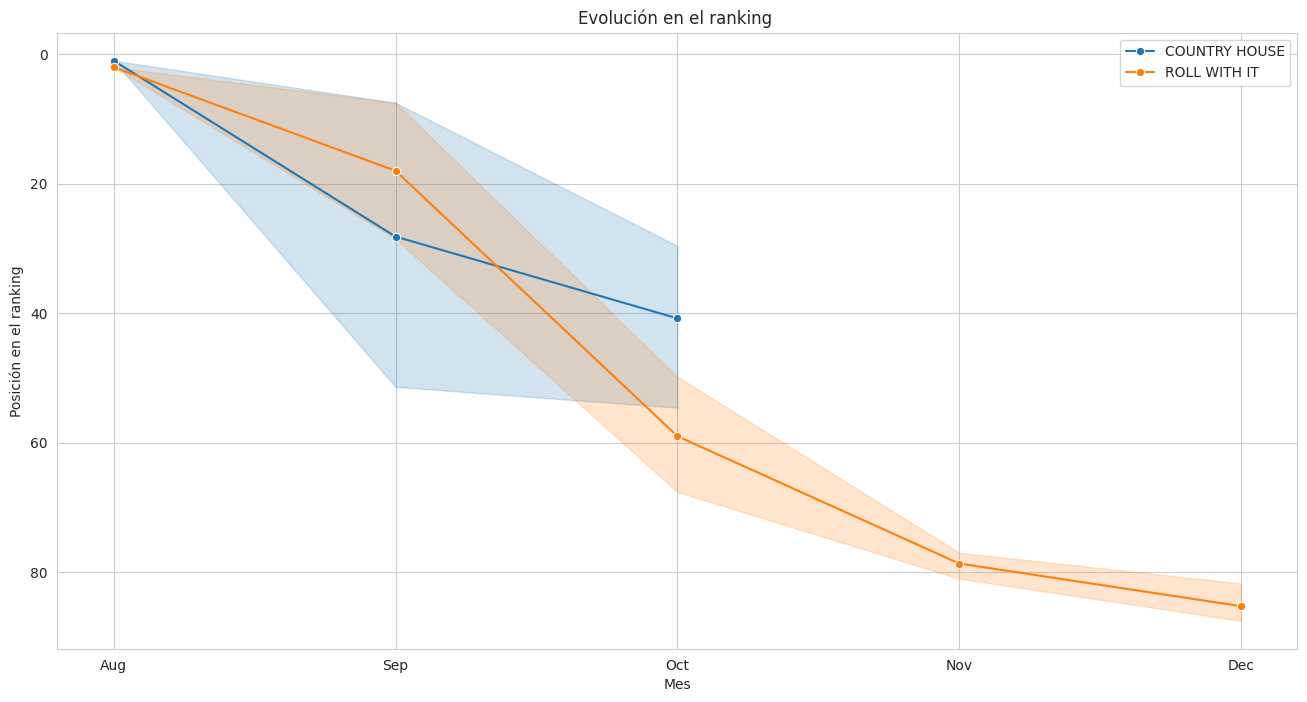

In [28]:
plt.figure(figsize=(16,8))
sns.set_style("whitegrid")
plt.gca().invert_yaxis()
sns.lineplot(data=df_tracks_b_o, x='Month', y='Position', hue='Song', marker='o')
plt.title("Evolución en el ranking ")
plt.xlabel("Mes")
plt.ylabel("Posición en el ranking")
plt.legend()
plt.grid(True)
plt.show()

##Semanas en el top 5 por canción

In [29]:
df_top_5_cancion = df_tracks_b_o[df_tracks_b_o['Position']<= 5]

sem_x_cancion = (
    df_top_5_cancion.groupby('Song').size().sort_values(ascending=False)
)


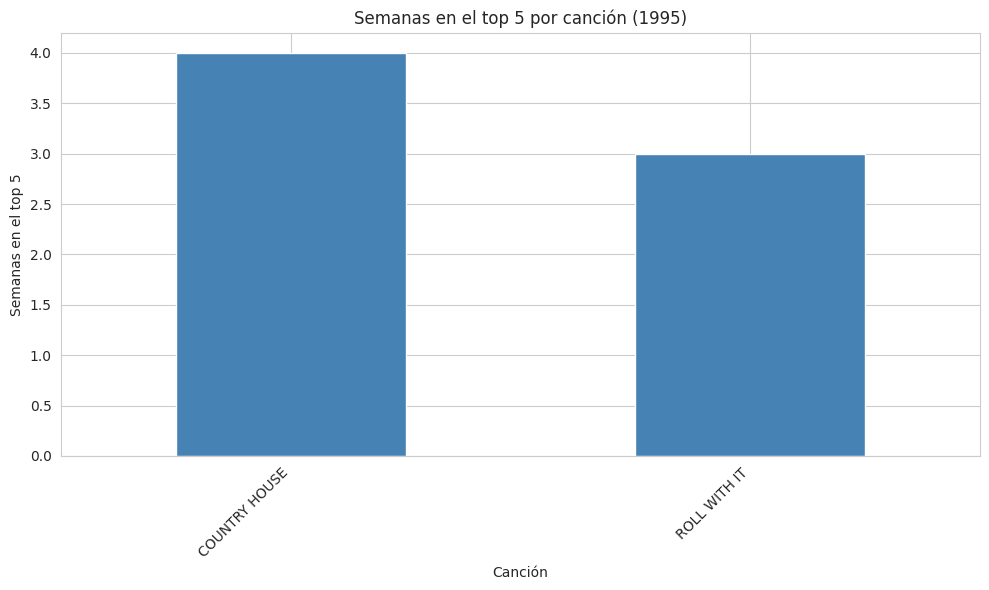

In [30]:
sem_x_cancion.plot(kind='bar', figsize=(10,6), color='steelblue')
plt.xlabel("Canción")
plt.ylabel("Semanas en el top 5")
plt.title("Semanas en el top 5 por canción (1995)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##Semanas en el top 5 por artista

In [31]:
df_top_5_b_o = df_100_blur_oasis[df_100_blur_oasis['Position']<= 5]

sem_x_cancion_b_o = (
    df_top_5_b_o.groupby('Artist').size().sort_values(ascending=False)
)

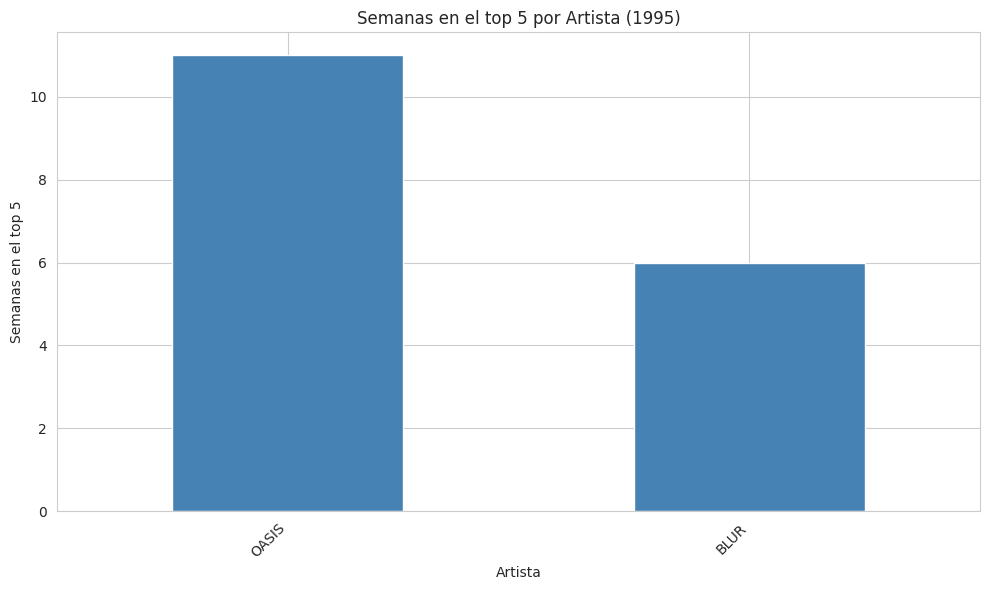

In [32]:
sem_x_cancion_b_o.plot(kind='bar', figsize=(10,6), color='steelblue')
plt.xlabel("Artista")
plt.ylabel("Semanas en el top 5")
plt.title("Semanas en el top 5 por Artista (1995)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##Comparación de canciones mas populares de Blur y Oasis

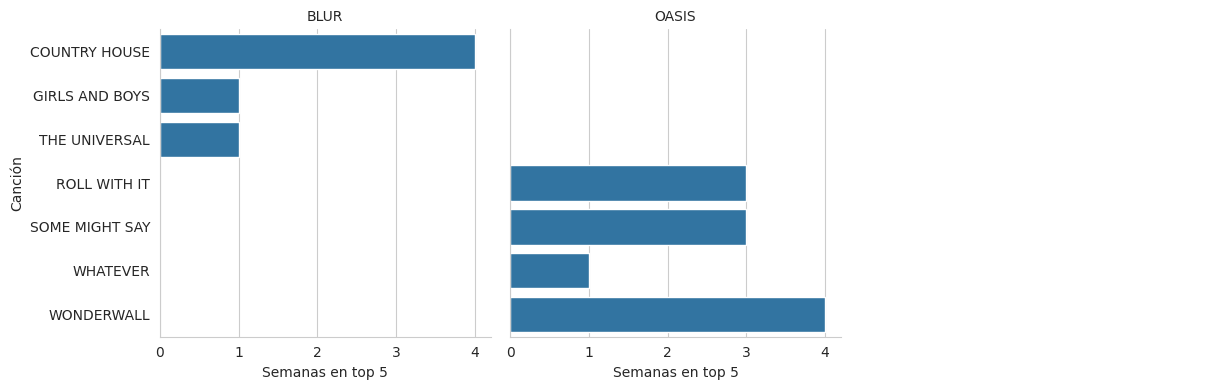

In [33]:
counts = (df_top_5_b_o.groupby(['Artist','Song']).size().reset_index(name='Weeks_top_5'))

gr = sns.catplot(data=counts, x='Weeks_top_5', y='Song', col='Artist', kind='bar', col_wrap=3, height=4, sharex=False)
gr.set_titles("{col_name}")
gr.set_axis_labels("Semanas en top 5", "Canción")
plt.tight_layout()
plt.show()

###Popularidad de Blur Vs. Oasis en la actualidad

In [34]:
filtro = df_b_o_juntos[df_b_o_juntos['popularity'] > 35]

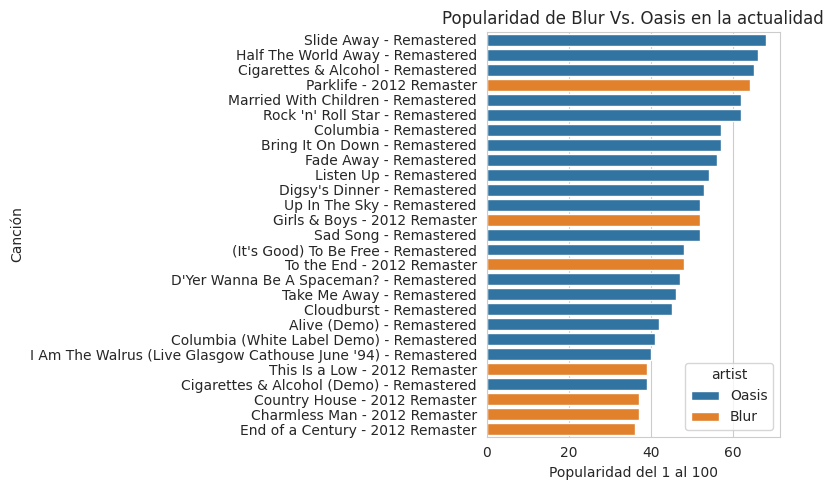

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(data=filtro.sort_values('popularity', ascending=False), x='popularity', y='track_name', hue='artist', dodge=False)

#plt.xticks(rotation=45, ha='right')
plt.ylabel("Canción")
plt.xlabel("Popularidad del 1 al 100")
plt.title("Popularidad de Blur Vs. Oasis en la actualidad")
plt.tight_layout()
plt.show()

##Entrenamiento del modelo de arboles de decisión

In [36]:
df2 = df_100_blur_oasis.copy()
print(df2.head())

                Song Artist  Position Last Week  Peak  Weeks on Chart  \
879   GIRLS AND BOYS   BLUR         5    LW:New     5               1   
980   GIRLS AND BOYS   BLUR         6      LW:5     5               2   
1086  GIRLS AND BOYS   BLUR        12      LW:6     5               3   
1190  GIRLS AND BOYS   BLUR        16     LW:12     5               4   
1300  GIRLS AND BOYS   BLUR        26     LW:16     5               5   

                              Week  
879   13 March 1994- 19 March 1994  
980   20 March 1994- 26 March 1994  
1086   27 March 1994- 2 April 1994  
1190    3 April 1994- 9 April 1994  
1300  10 April 1994- 16 April 1994  


In [37]:
agg_df2 = df2.groupby(['Song','Artist']).agg(
    initial_position=('Position','first'),
    peak_position=('Position','min'),
    weeks_on_chart=('Week','count')
).reset_index()

agg_df2 = agg_df2[agg_df2['peak_position'] <= 20]


agg_df2['success_type'] = (agg_df2['weeks_on_chart'] >= 8).map(
    {True: 'Duradero', False: 'Momentaneo'}
)

In [38]:
x = agg_df2[['initial_position', 'peak_position', 'Artist']]
y = agg_df2['success_type']

encoder = OneHotEncoder(sparse_output=False)
artist_encoded = encoder.fit_transform(x[['Artist']])
artist_df2 = pd.DataFrame(artist_encoded, columns=encoder.get_feature_names_out(['Artist']), index=x.index)

x_num = pd.concat([x, artist_df2], axis=1).drop(columns=['Artist'])

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x_num, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
tree_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42)

tree_clf.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [41]:
y_pred_tree = tree_clf.predict(x_test)

print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))

              precision    recall  f1-score   support

    Duradero       1.00      1.00      1.00         2
  Momentaneo       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

[[2 0]
 [0 1]]


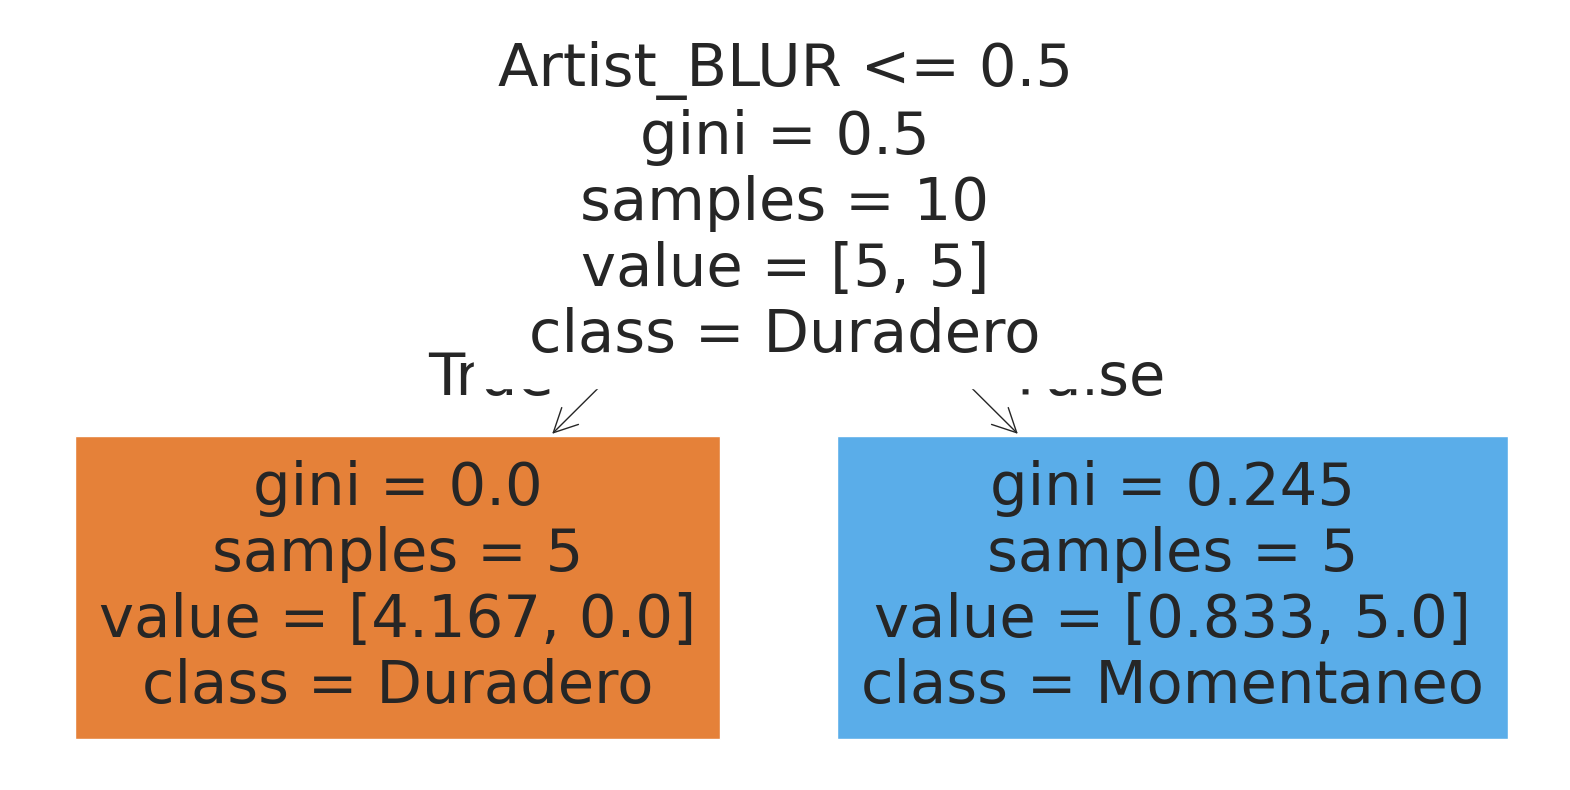

In [42]:
plt.figure(figsize=(20,10))
plot_tree(tree_clf,
          filled=True,
          feature_names=x_num.columns,
          class_names=['Duradero', 'Momentaneo'])
plt.show()